In [3]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [4]:
torch.backends.mkldnn.enabled = True

In [5]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [6]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.MaxPool2d(2),          # 32 → 16
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 16 → 8
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.MaxPool2d(2),          # 8 → 4
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 4 → 2
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [7]:
model16_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model16_0)
describe(model16_0)

MACs: 4.2 MMac, Params: 48.51 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─MaxPool2d: 3-10              [1, 30, 16, 

Loading checkpoint from model_weights/model16_0.pt
Starting
Epoch 1/60: Train loss = 1.0611, Train accuracy = 0.6205, Test loss = 1.0281, Test accuracy = 0.6389
Epoch 2/60: Train loss = 0.9153, Train accuracy = 0.6817, Test loss = 0.8974, Test accuracy = 0.6889
Epoch 3/60: Train loss = 0.7931, Train accuracy = 0.7223, Test loss = 0.7922, Test accuracy = 0.7211
Epoch 4/60: Train loss = 0.7644, Train accuracy = 0.7323, Test loss = 0.7486, Test accuracy = 0.7416
Epoch 5/60: Train loss = 0.7532, Train accuracy = 0.7370, Test loss = 0.7493, Test accuracy = 0.7406
Epoch 6/60: Train loss = 0.7048, Train accuracy = 0.7581, Test loss = 0.7110, Test accuracy = 0.7640
Epoch 7/60: Train loss = 0.6237, Train accuracy = 0.7819, Test loss = 0.6277, Test accuracy = 0.7851
Epoch 8/60: Train loss = 0.6050, Train accuracy = 0.7897, Test loss = 0.6302, Test accuracy = 0.7815
Epoch 9/60: Train loss = 0.6358, Train accuracy = 0.7769, Test loss = 0.6500, Test accuracy = 0.7720
Epoch 10/60: Train loss = 0.585

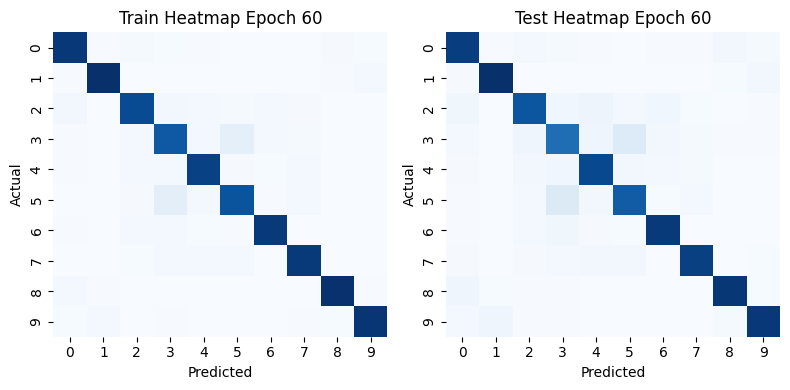

<Figure size 1200x600 with 0 Axes>

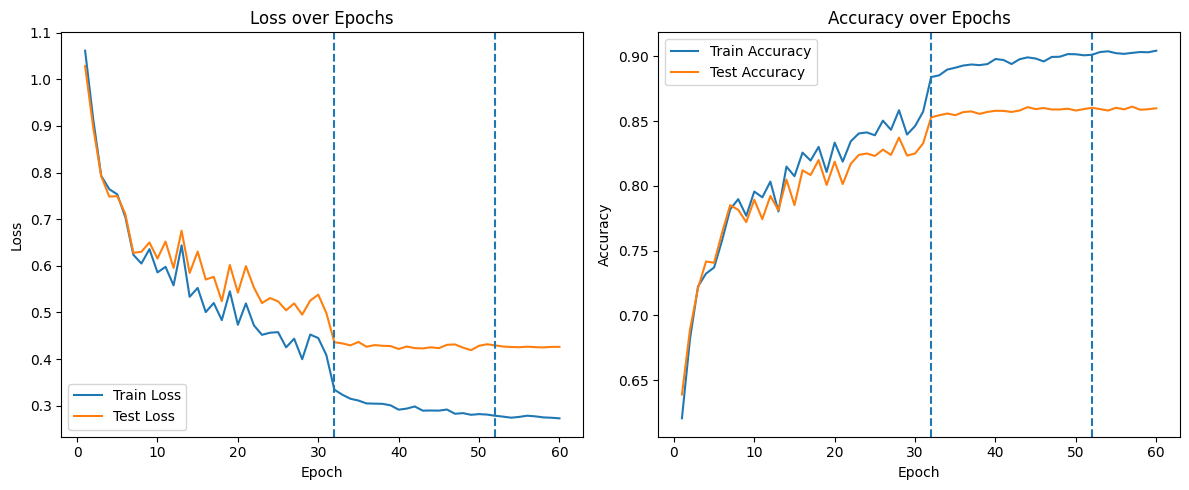

In [8]:
trainf32(model16_0,"model_weights/model16_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [9]:
model16_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model16_1)
describe(model16_1)

MACs: 4.2 MMac, Params: 48.51 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─MaxPool2d: 3-10              [1, 30, 16, 

Starting
Epoch 1/60: Train loss = 1.0459, Train accuracy = 0.6285, Test loss = 1.0316, Test accuracy = 0.6378
Epoch 2/60: Train loss = 0.9033, Train accuracy = 0.6837, Test loss = 0.8549, Test accuracy = 0.7012
Epoch 3/60: Train loss = 0.8268, Train accuracy = 0.7117, Test loss = 0.8200, Test accuracy = 0.7125
Epoch 4/60: Train loss = 0.7747, Train accuracy = 0.7267, Test loss = 0.7757, Test accuracy = 0.7317
Epoch 5/60: Train loss = 0.6803, Train accuracy = 0.7604, Test loss = 0.7029, Test accuracy = 0.7534
Epoch 6/60: Train loss = 0.6418, Train accuracy = 0.7771, Test loss = 0.6498, Test accuracy = 0.7742
Epoch 7/60: Train loss = 0.6283, Train accuracy = 0.7800, Test loss = 0.6692, Test accuracy = 0.7646
Epoch 8/60: Train loss = 0.6020, Train accuracy = 0.7896, Test loss = 0.6330, Test accuracy = 0.7807
Epoch 9/60: Train loss = 0.5559, Train accuracy = 0.8063, Test loss = 0.5757, Test accuracy = 0.8038
Epoch 10/60: Train loss = 0.5632, Train accuracy = 0.8024, Test loss = 0.5959, Tes

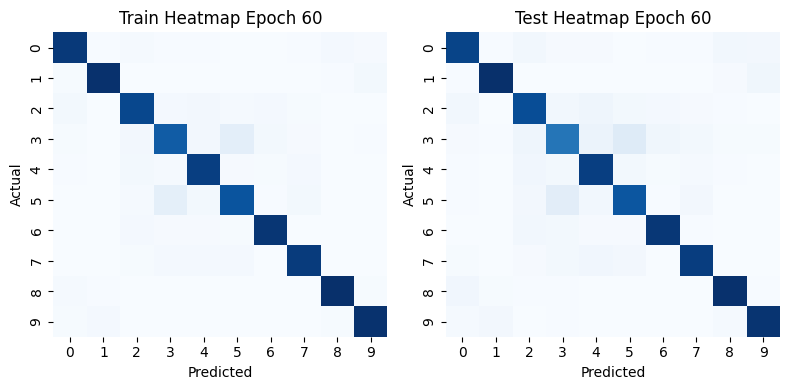

<Figure size 1200x600 with 0 Axes>

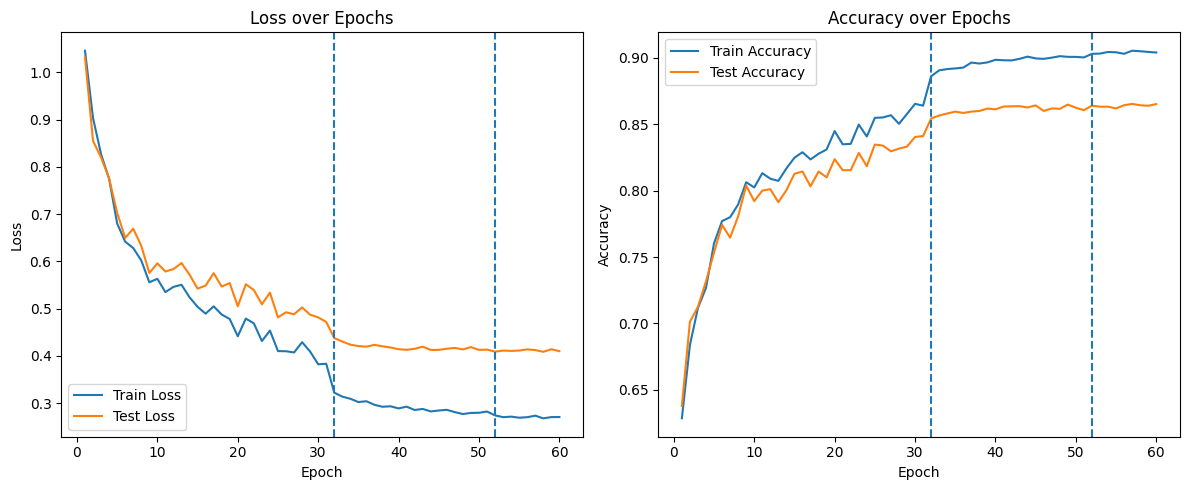

In [10]:
trainf32(model16_1,"model_weights/model16_1.pt",criterion,train_dataset,val_dataset, batch_size=64)